- By Nabankur Ray

**Context**

In today’s competitive real estate market, accurate property price prediction is critical for buyers, sellers, agents, and investors to make informed decisions. Pricing a property too high can deter potential buyers, while undervaluing a property leads to financial loss.

 This project aims to develop and evaluate machine learning models to predict house prices in an urban environment (simulated as Paris) using various property features such as square meter, number of rooms, location attributes, and amenities like pools or yards.

**Data Description**

Dataset Used is "**ParisHousing.csv**"

*source: https://www.kaggle.com/datasets/mssmartypants/paris-housing-price-prediction/data*


* **squareMeters:** Area of the house

* **numberOfRooms:**  Total number of rooms

* **hasYard:** 1 = Has yard, 0 = No yard

* **hasPool:** 1 = Has swimming pool

* **floors:** Number of floors

* **cityCode:** City zip code

* **cityPartRange:** Higher = more exclusive area

* **numPrevOwners:** Number of previous owners

* **made:** Year of construction

* **isNewBuilt:** 1 = Newly built

* **hasStormProtector:** 1 = Has storm protector

* **basement:** Size of basement (m²)

* **attic:** Size of attic (m²)

* **garage:** Size of garage (m²)

* **hasStorageRoom:** 1 = Has storage room

* **hasGuestRoom:** Number of guest rooms

* **price:** Target variable (price of house)



# Import necessary libraries

In [ ]:
import pandas as pd      # For data manipulation and analysis
import numpy as np        # For numerical computations and array operations
import matplotlib.pyplot as plt        # For data visualization (basic plotting like line, bar, scatter plots)
import seaborn as sns                  # For advanced data visualization (especially statistical plots)
from sklearn.model_selection import train_test_split  # For splitting data into training/testing sets
from sklearn.impute import SimpleImputer  # For handling missing values
from sklearn.preprocessing import OneHotEncoder  # For encoding categorical variables

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x) # To display floating-point numbers with 3 decimal places

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

In [ ]:
# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Loading the Data sets

In [ ]:
# Loading the Datasets from the Drive
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading the Microclimate Sensor Data
data = pd.read_csv('/content/drive/My Drive/ParisHousing.csv')
data.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.500
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.500
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.100
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.200
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.000


# Data Understanding

In [ ]:
# Checking the shape of the data
data.shape

(10000, 17)

In [ ]:
# Checking the structure and data type of the given data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squareMeters       10000 non-null  int64  
 1   numberOfRooms      10000 non-null  int64  
 2   hasYard            10000 non-null  int64  
 3   hasPool            10000 non-null  int64  
 4   floors             10000 non-null  int64  
 5   cityCode           10000 non-null  int64  
 6   cityPartRange      10000 non-null  int64  
 7   numPrevOwners      10000 non-null  int64  
 8   made               10000 non-null  int64  
 9   isNewBuilt         10000 non-null  int64  
 10  hasStormProtector  10000 non-null  int64  
 11  basement           10000 non-null  int64  
 12  attic              10000 non-null  int64  
 13  garage             10000 non-null  int64  
 14  hasStorageRoom     10000 non-null  int64  
 15  hasGuestRoom       10000 non-null  int64  
 16  price              1000

*OBSERVATIONS*

* There are **10000 rows** and **17 Columns** are present in the given datasets.

* It can be observed that no columns have less entries (less than 10000 rows) which indicates that **there are no missing values in the given dataset.**

* There are attributes of different types (int & float) in the dataset.

* There only numerical columns (float) in the data and **no categorical columns**.

**Statistical summary of the dataset**

In [ ]:
# Numerical summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
squareMeters,10000.000,49870.131,28774.375,89.000,25098.500,50105.500,74609.750,99999.000
numberOfRooms,10000.000,50.358,28.817,1.000,25.000,50.000,75.000,100.000
hasYard,10000.000,0.509,0.500,0.000,0.000,1.000,1.000,1.000
hasPool,10000.000,0.497,0.500,0.000,0.000,0.000,1.000,1.000
floors,10000.000,50.276,28.889,1.000,25.000,50.000,76.000,100.000
cityCode,10000.000,50225.486,29006.676,3.000,24693.750,50693.000,75683.250,99953.000
cityPartRange,10000.000,5.510,2.872,1.000,3.000,5.000,8.000,10.000
numPrevOwners,10000.000,5.522,2.857,1.000,3.000,5.000,8.000,10.000
made,10000.000,2005.488,9.308,1990.000,1997.000,2005.500,2014.000,2021.000
isNewBuilt,10000.000,0.499,0.500,0.000,0.000,0.000,1.000,1.000


In [ ]:
# checking the number of unique values
data.nunique()

,0
squareMeters,9483
numberOfRooms,100
hasYard,2
hasPool,2
floors,100
cityCode,9509
cityPartRange,10
numPrevOwners,10
made,32
isNewBuilt,2


**Checking for Missing Values**

In [ ]:
# checking for the duplicate values
data.duplicated().sum()

np.int64(0)

In [ ]:
# Printing the No. of Missing Values in sorted order
missing_value_count = data.isnull().sum()
missing_value_count_sorted = missing_value_count.sort_values(ascending=False)
missing_value_count_sorted

,0
squareMeters,0
numberOfRooms,0
hasYard,0
hasPool,0
floors,0
cityCode,0
cityPartRange,0
numPrevOwners,0
made,0
isNewBuilt,0


In [ ]:
# Checking the total number of missing values
total_missing = missing_value_count.sum()

print(f"Total number of missing values: {total_missing}")

Total number of missing values: 0


# Exploratory Data Analysis

## Univariate Analysis

In [ ]:
# Checking the No. of unique in "cityCode" column
print(f"No. of values in cityCode: {data['cityCode'].nunique()}")

No. of values in cityCode: 9509


The feature **cityCode** has **9,509** unique values, indicating that it likely represents a high-cardinality categorical variable

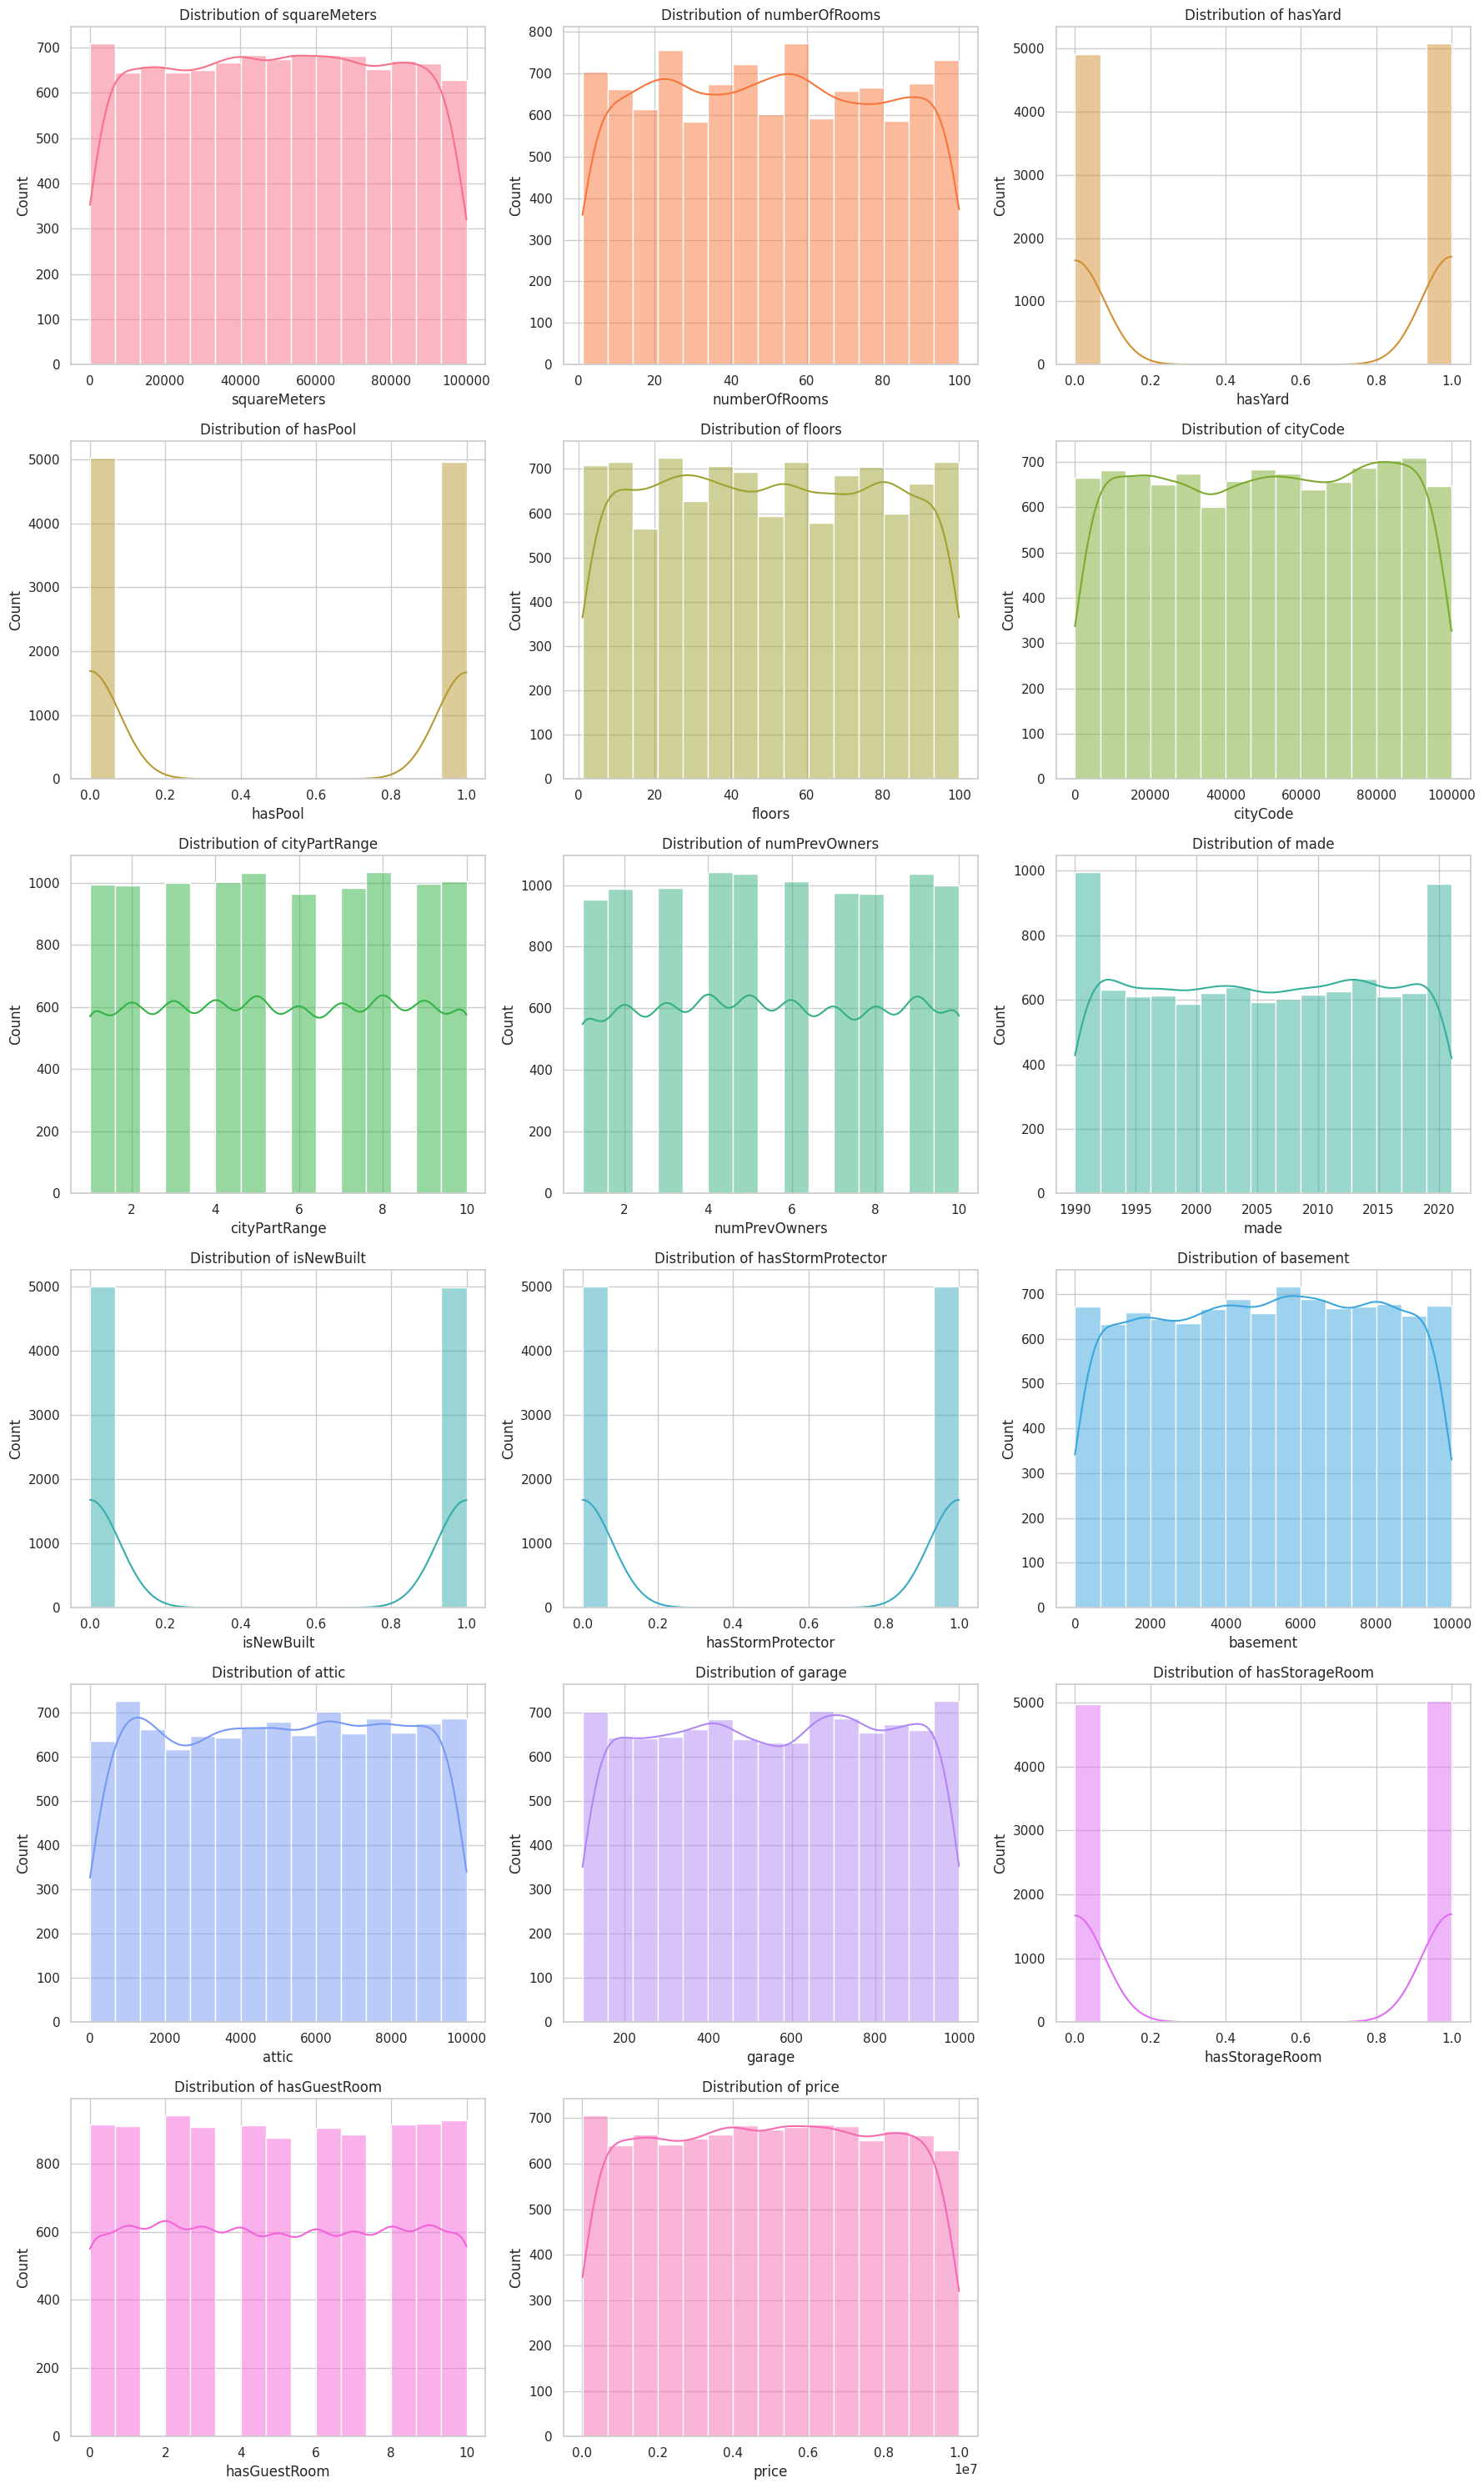

In [ ]:
# Define a custom color palette
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

colors = sns.color_palette("husl", len(numeric_cols))  # can also try "Set2", "pastel", for different colour pattern

# Set number of plots per row
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# Plot each numeric column
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True, color=colors[i], bins=15)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

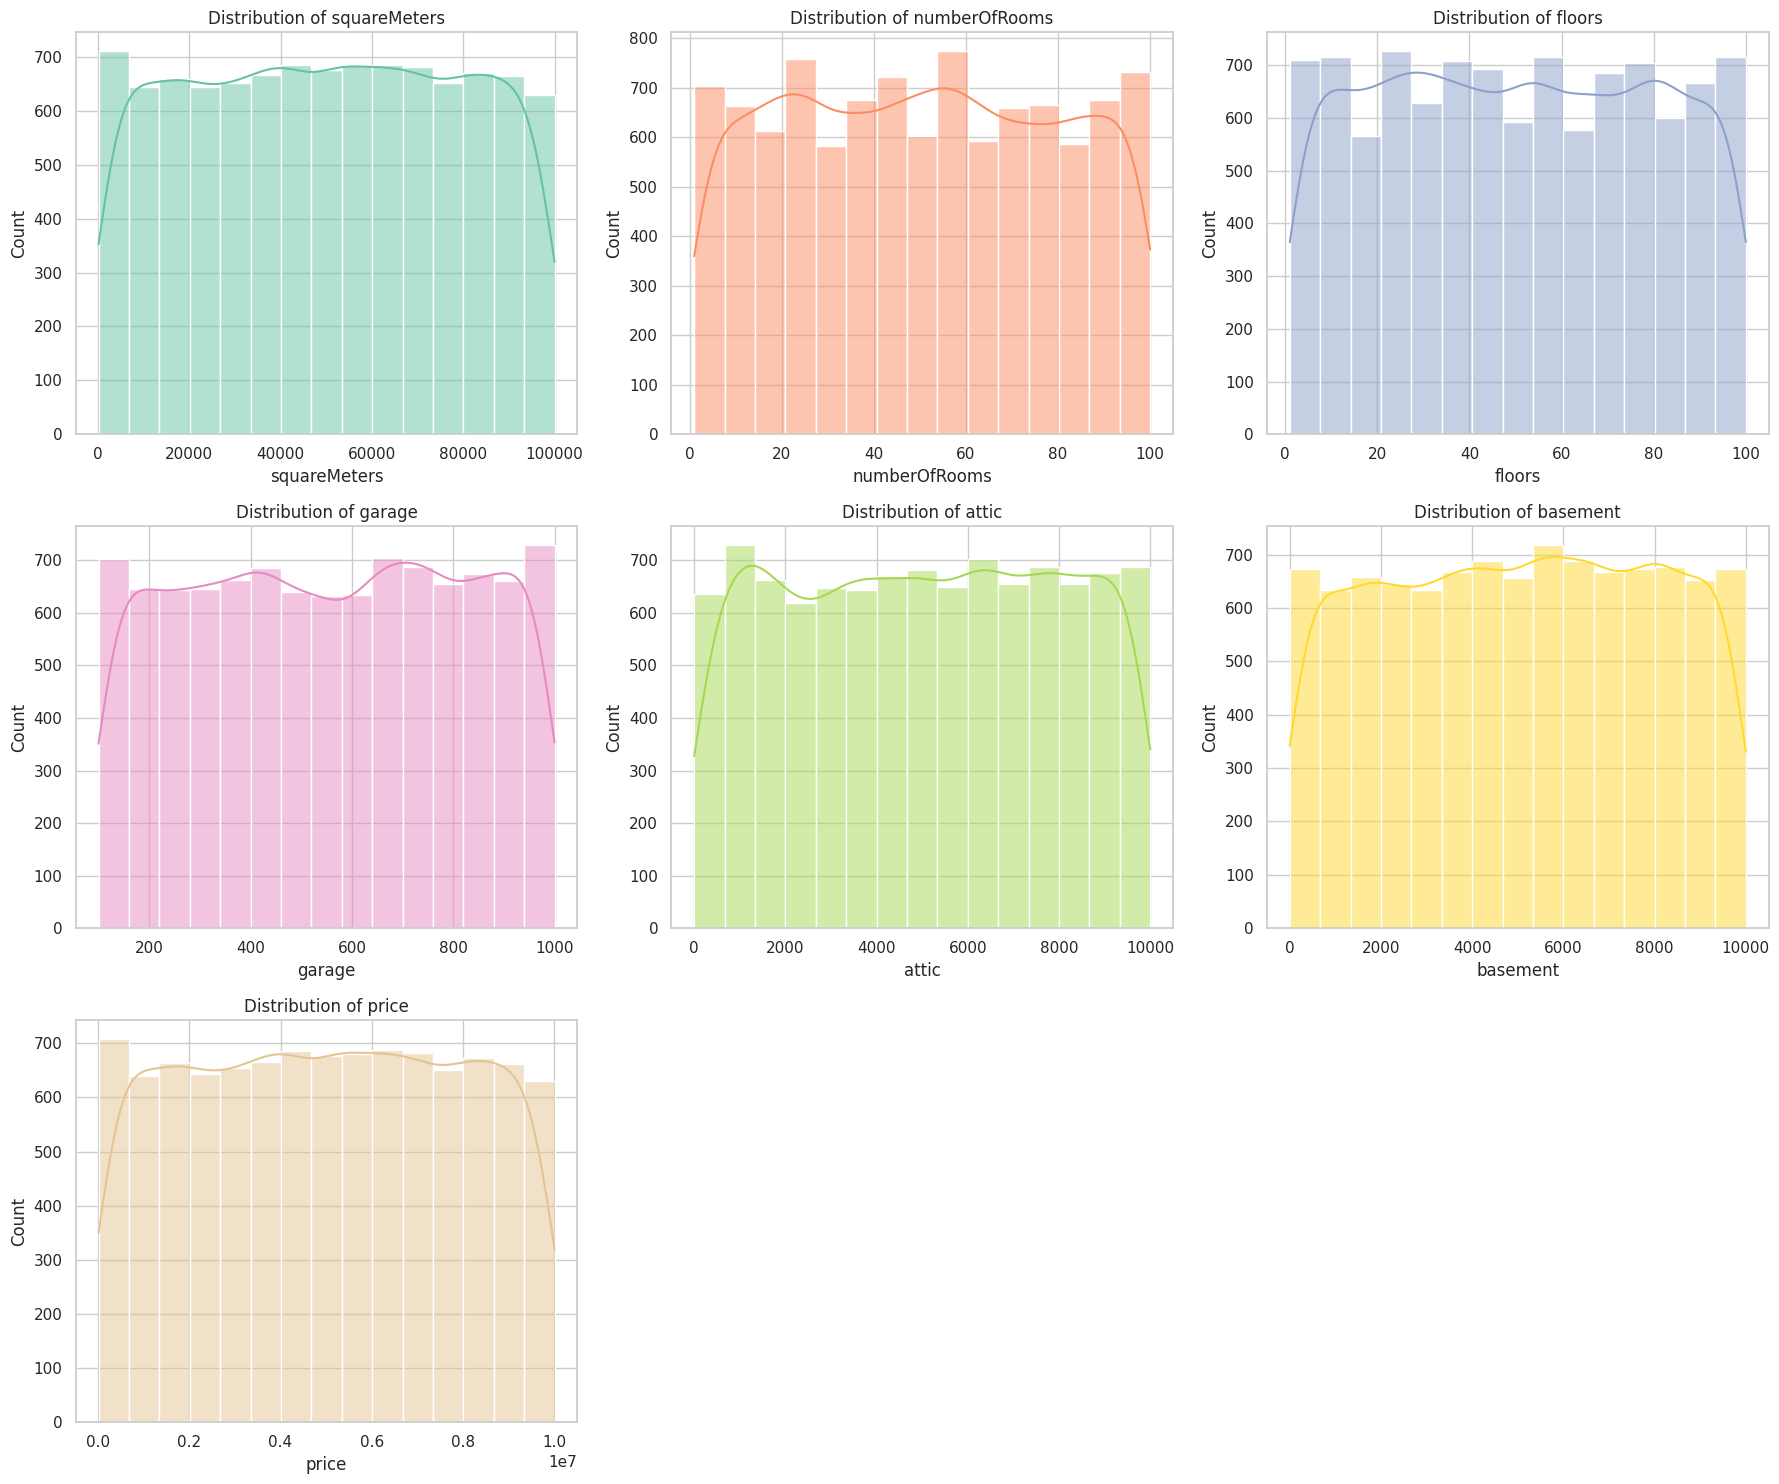

In [ ]:
# Select only the required columns
selected_cols = ['squareMeters', 'numberOfRooms', 'floors', 'garage', 'attic', 'basement', 'price']

# Define custom color palette for selected columns
colors = sns.color_palette("Set2", len(selected_cols))

# Set number of plots per row
n_cols = 3
n_rows = (len(selected_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# Plot each selected numeric column
for i, col in enumerate(selected_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True, color=colors[i], bins=15)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


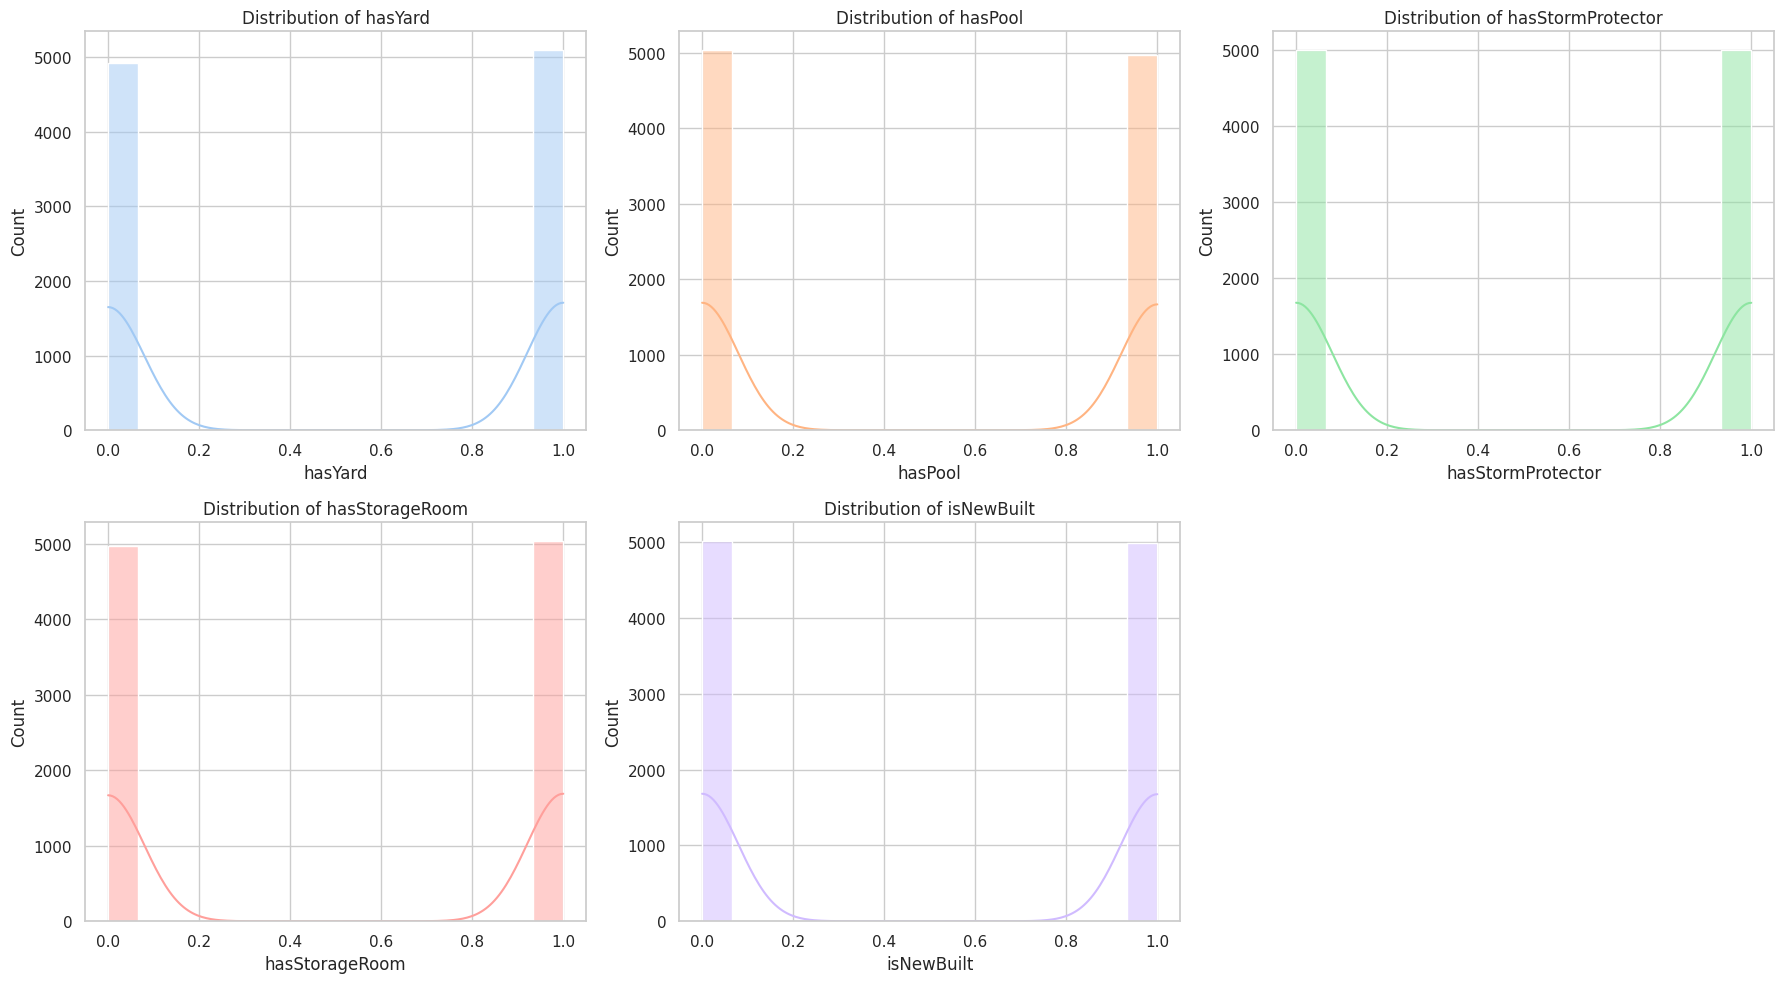

In [ ]:
# Select only the required columns
selected_cols1 = ['hasYard', 'hasPool', 'hasStormProtector', 'hasStorageRoom', 'isNewBuilt']

# Define custom color palette for selected columns
colors = sns.color_palette("pastel", len(selected_cols))

# Set number of plots per row
n_cols = 3
n_rows = (len(selected_cols1) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# Plot each selected numeric column
for i, col in enumerate(selected_cols1):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True, color=colors[i], bins=15)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


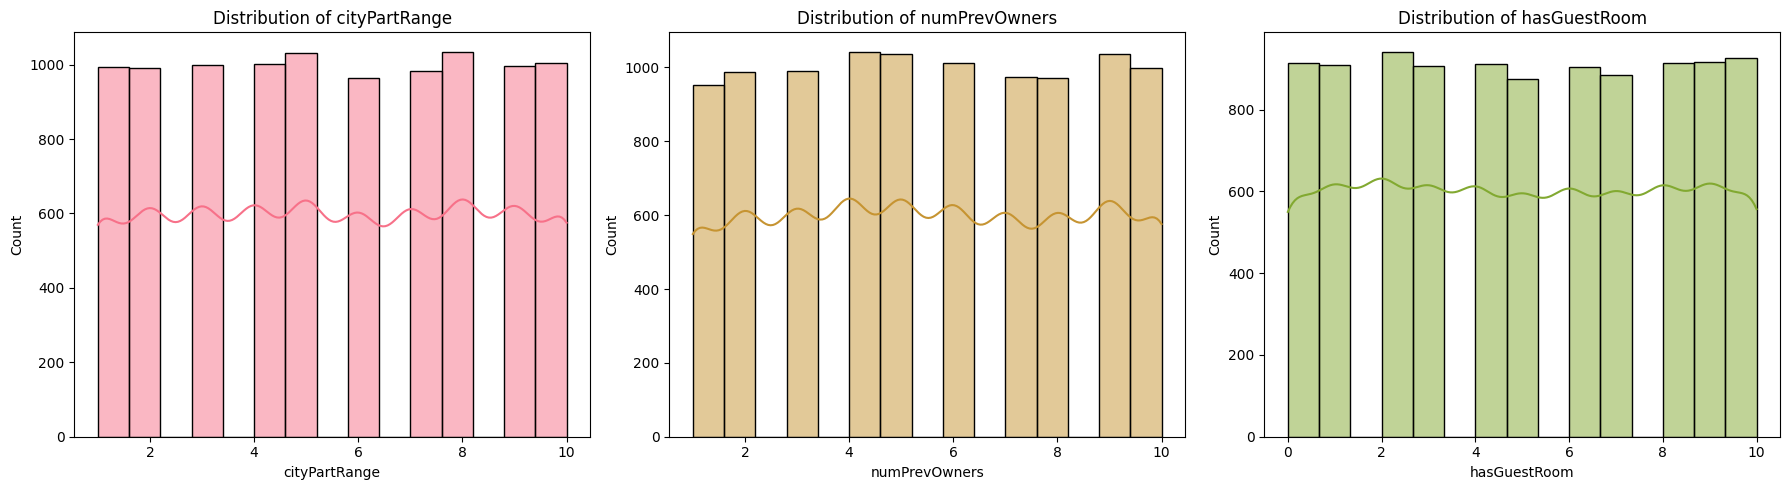

In [ ]:
# Select only the required columns
selected_cols2 = ['cityPartRange', 'numPrevOwners', 'hasGuestRoom']

# Define custom color palette for selected columns
colors = sns.color_palette("husl", len(selected_cols))

# Set number of plots per row
n_cols = 3
n_rows = (len(selected_cols2) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# Plot each selected numeric column
for i, col in enumerate(selected_cols2):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True, color=colors[i], bins=15)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


*INSIGHTS*

* Most numeric features (**squareMeters, numberOfRooms, floors, garage, attic, basement, price,**) are evenly distributed across their ranges, suggesting the data may be synthetically generated or highly engineered. Natural housing data usually shows skewness or clusters.

* Binary variables (**hasYard, hasPool, hasStormProtector, hasStorageRoom, isNewBuilt**) all have close to a 50:50 distribution, ideal for modeling but uncommon in real-world scenarios—again pointing to simulated balance.

* Features like **cityPartRange, numPrevOwners, and hasGuestRoom** show discrete distributions with nearly equal frequency across categories, making them stable for one-hot encoding or ordinal encoding.

* The **price** variable is **uniformly distributed**, which is not typical for real estate data that usually skews toward lower values. This could impact regression models by making it harder to generalize to real-world scenarios.

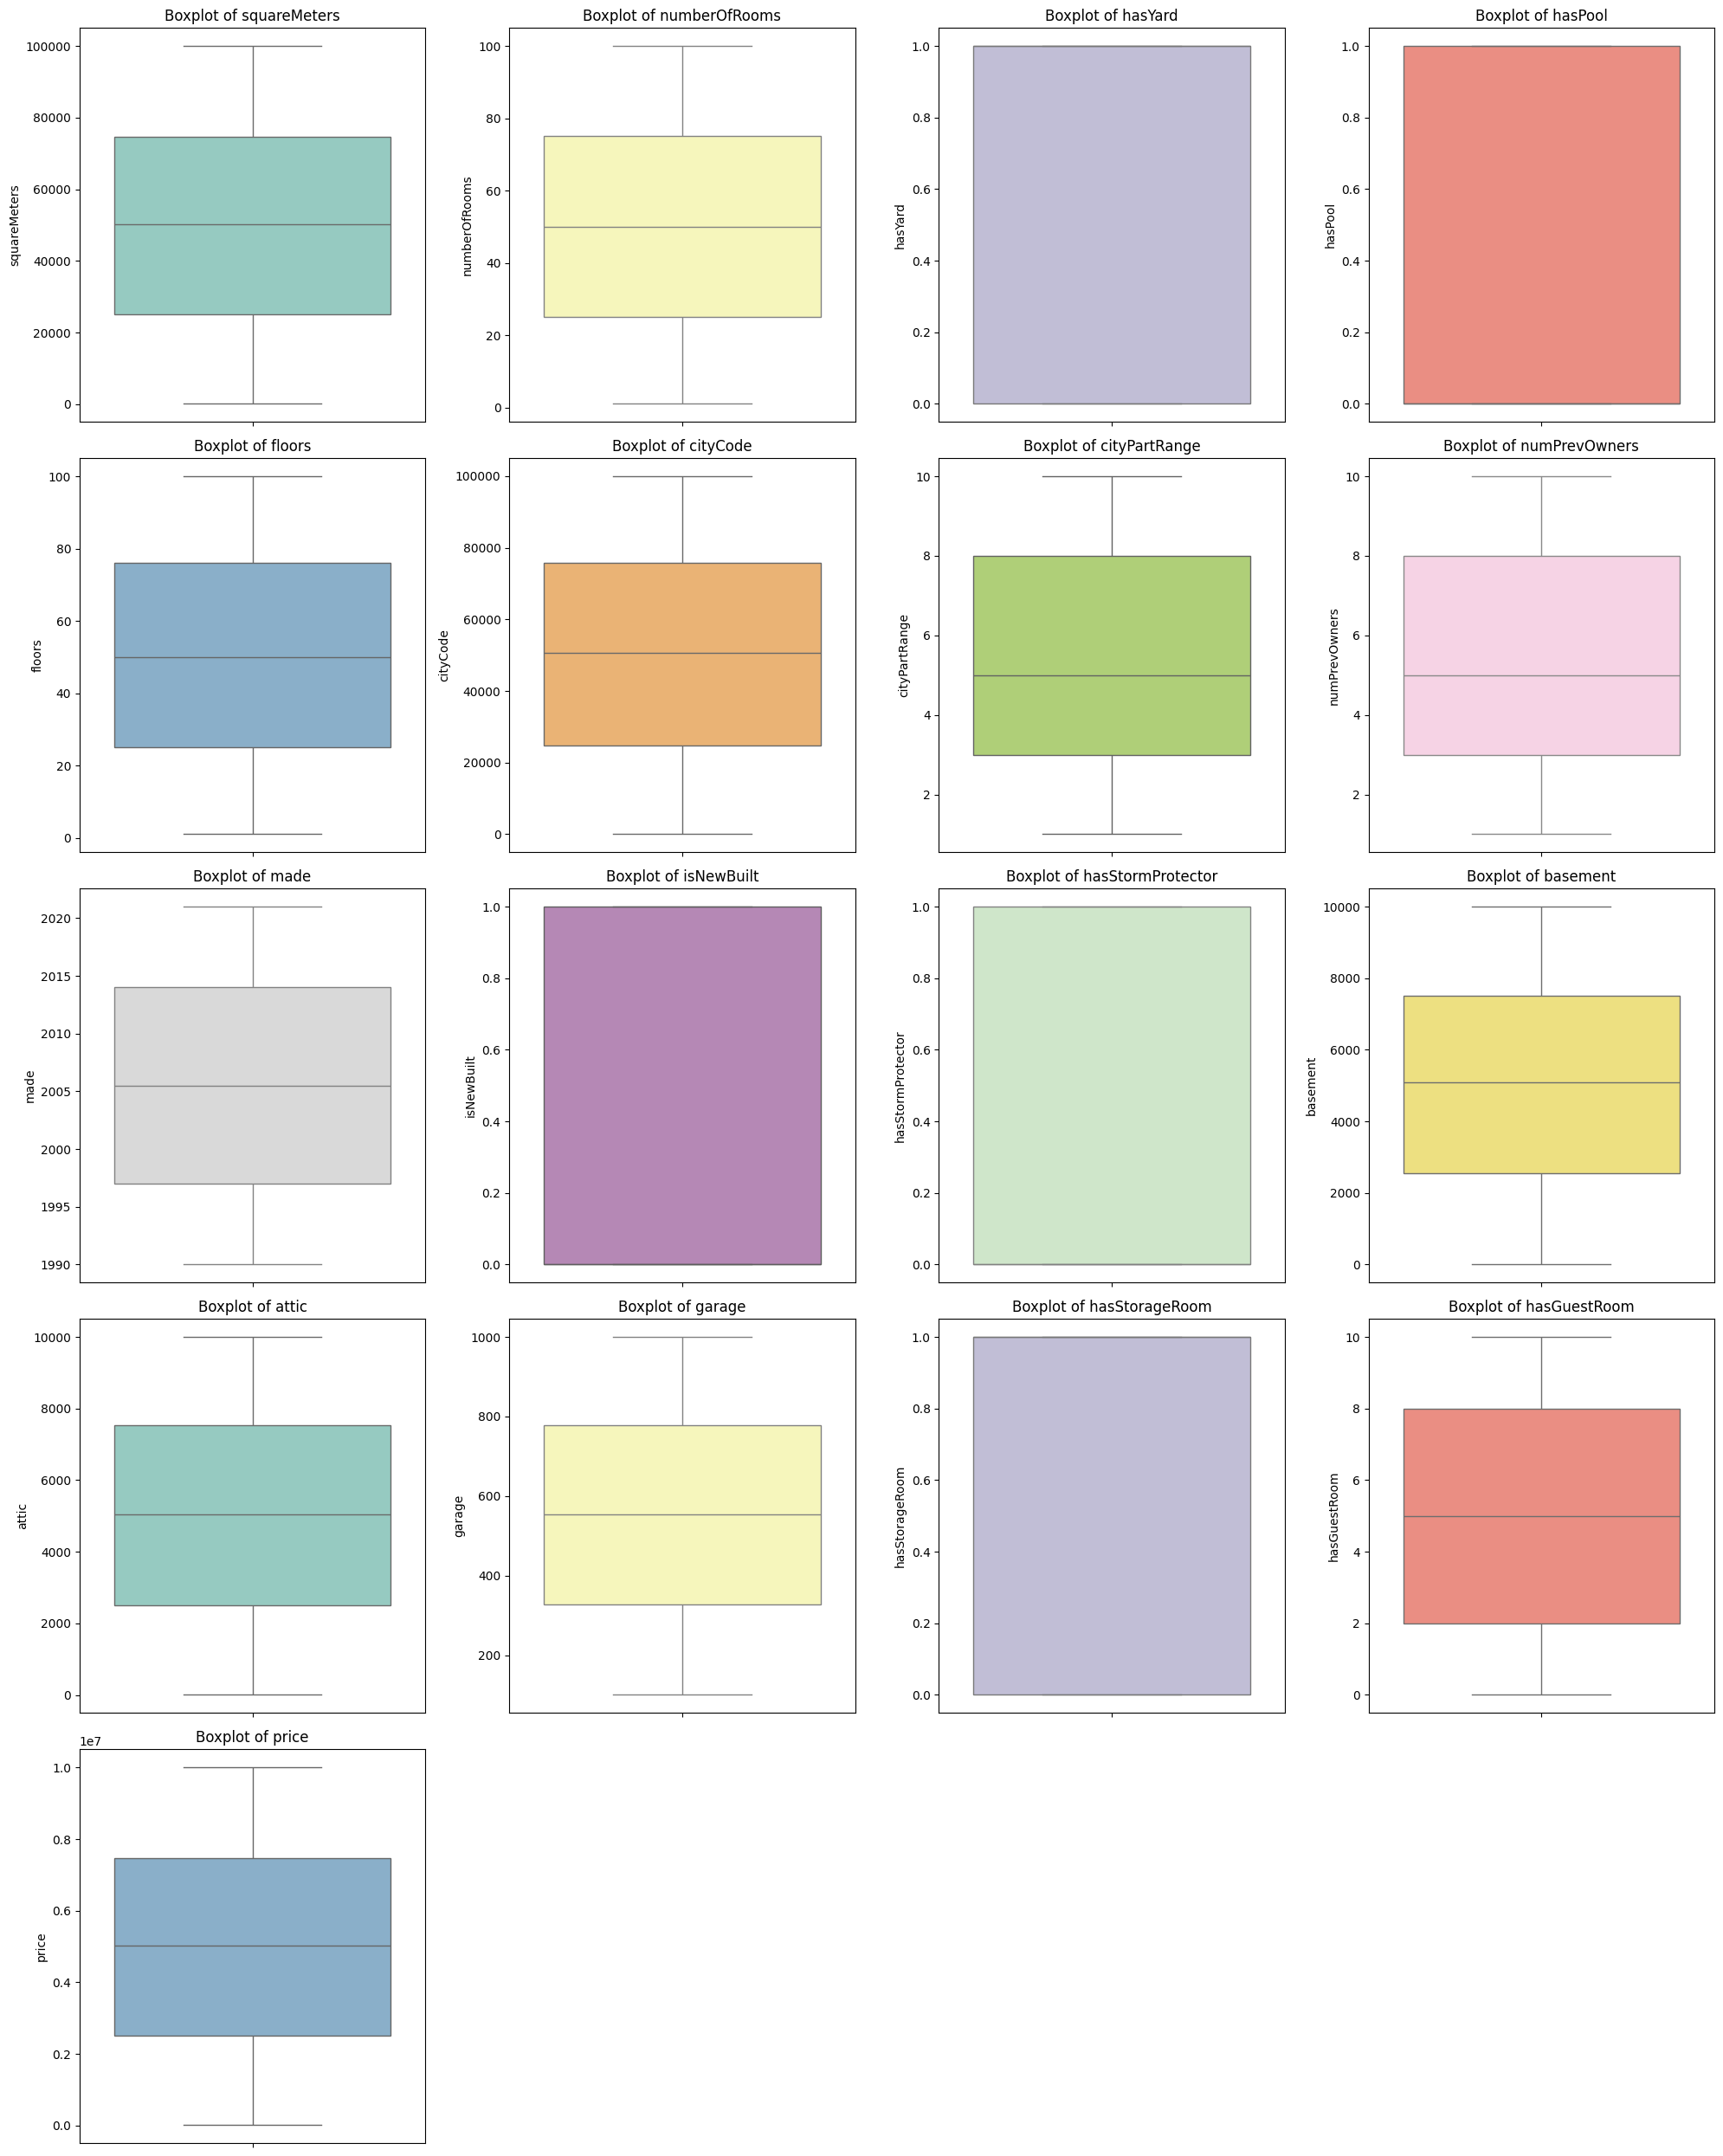

In [ ]:
# Define a color palette
colors = sns.color_palette("Set3", len(numeric_cols))  # Options: "pastel", "husl", "Set2"

# Set up plotting area with 4 subplots per row
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # Ceiling division

plt.figure(figsize=(20, 5 * n_rows))  # Adjust figure width for 4 plots per row

# Plot each numeric column as a boxplot
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=data, y=col, color=colors[i])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


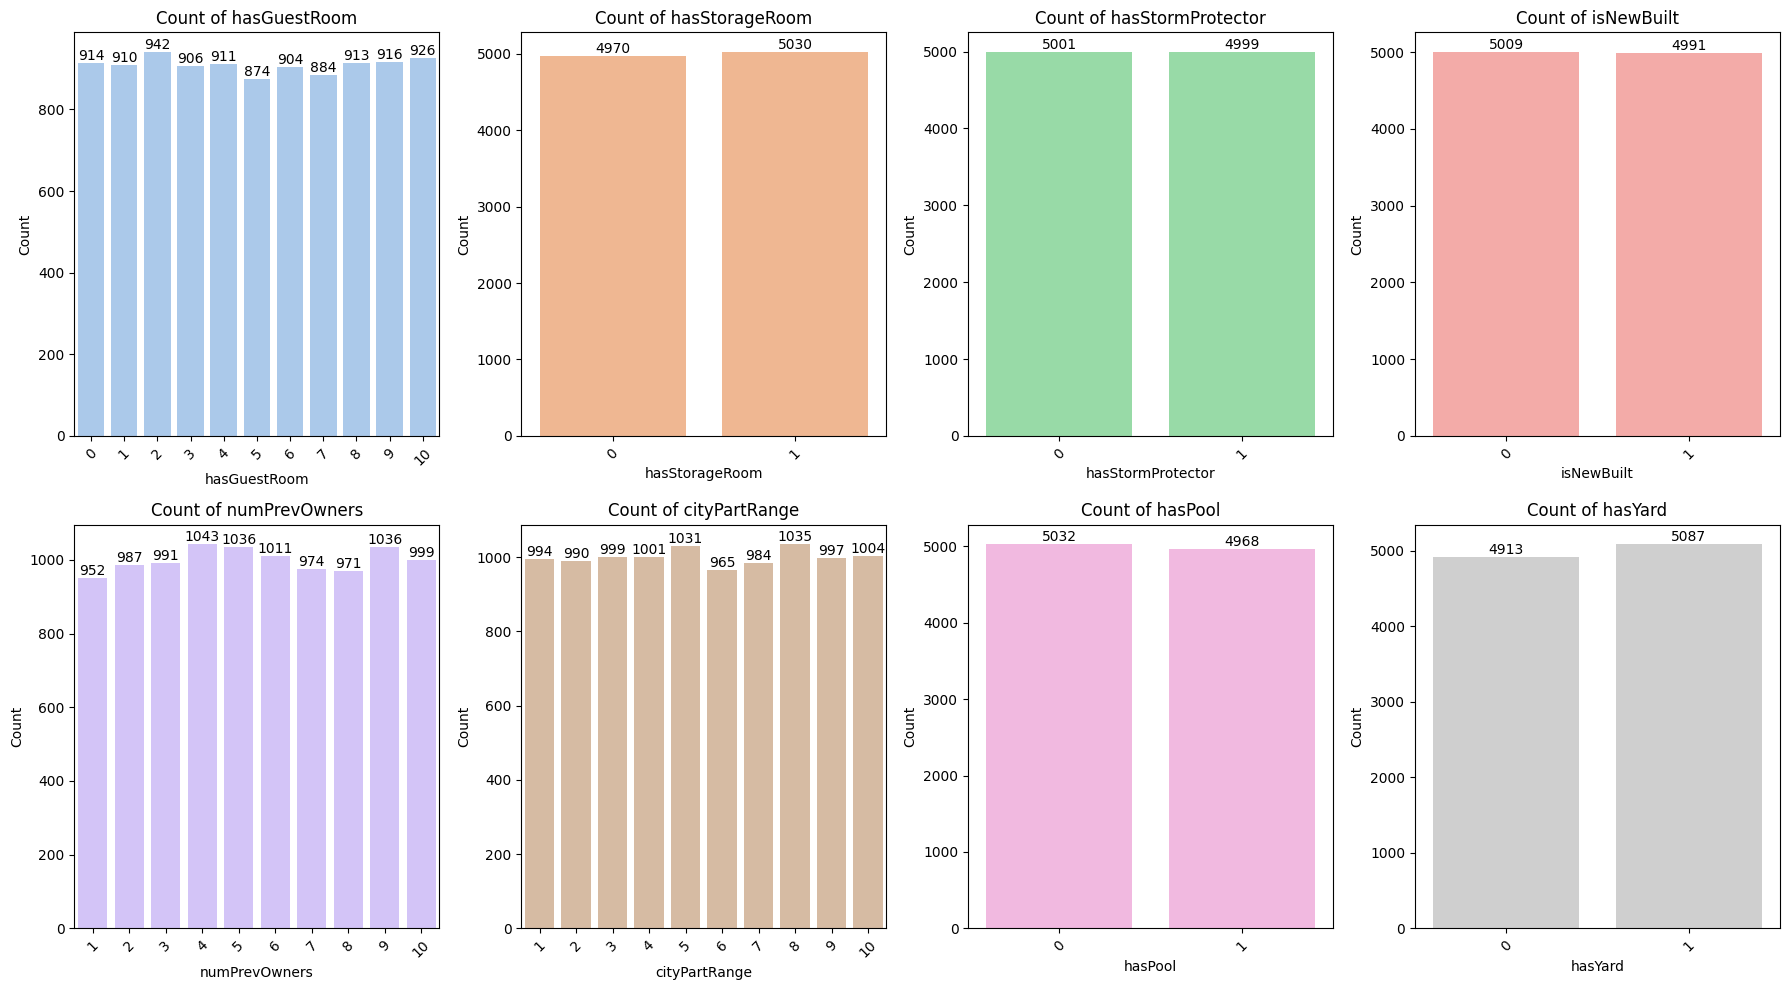

In [ ]:
categorical_cols = ['hasGuestRoom', 'hasStorageRoom', 'hasStormProtector', 'isNewBuilt', 'numPrevOwners', 'cityPartRange', 'hasPool', 'hasYard']
# Define a color palette
colors = sns.color_palette("pastel", len(categorical_cols))  # You can also try: "Set2", "husl", etc.

# Plot layout
n_cols = 4  # Number of plots per row
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# Create bar plots for each categorical variable
for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    ax = sns.countplot(data=data, x=col, color=colors[i])
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


*INSIGHTS*

* Binary Variables - **hasYard, hasPool, isNewBuilt, hasStormProtector,** and **hasStorageRoom** are fairly balanced with counts close to 50-50. This suggests minimal class imbalance and supports fair learning.

* **hasGuestRoom** ranges from 0 to 10 with a roughly uniform distribution, indicating homes vary significantly in accommodation capacity.

* **numPrevOwners** and **cityPartRange** also shows even distribution from 1 to 10.

# Bivariate Analysis

Correlation Heatmap

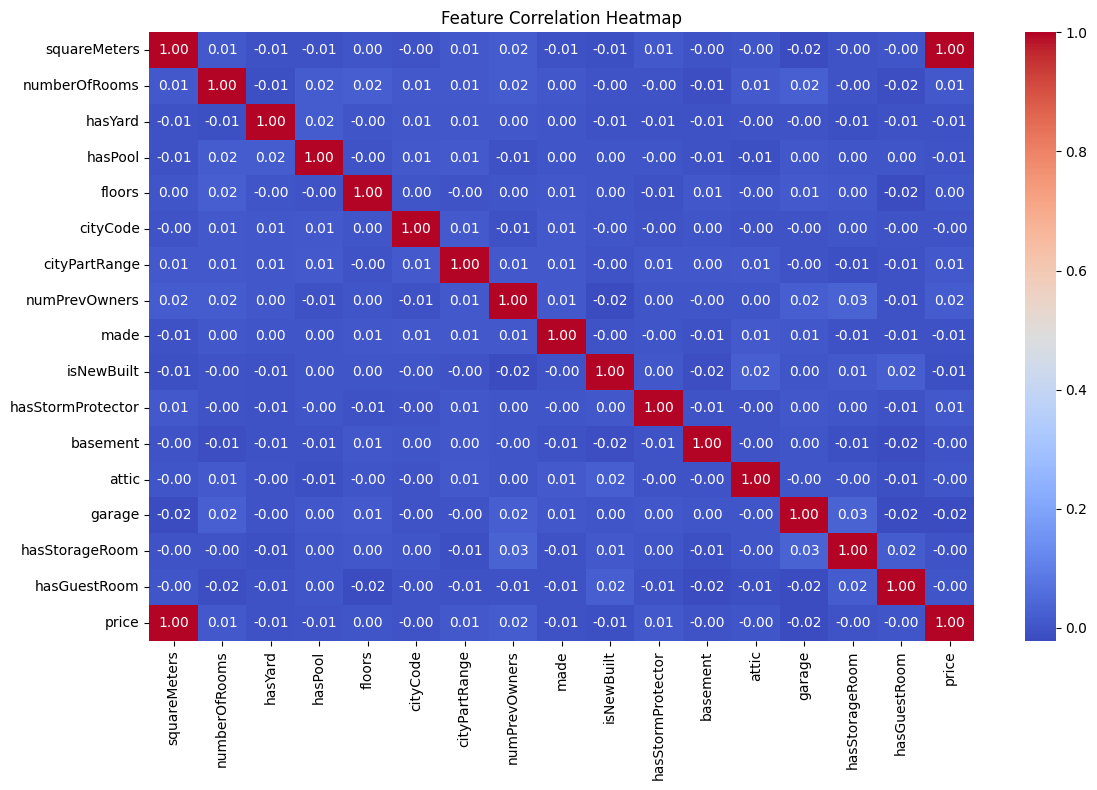

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

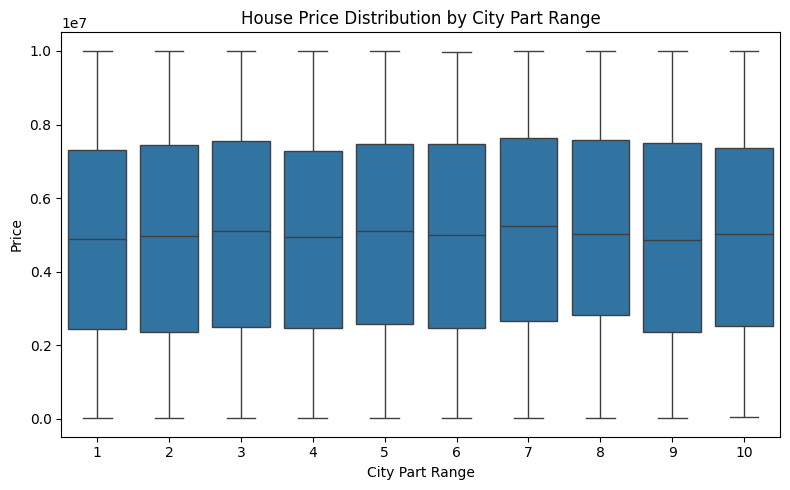

In [ ]:
# Boxplot of Price by City Part Range (proxy for region)
plt.figure(figsize=(8, 5))
sns.boxplot(x='cityPartRange', y='price', data=df)
plt.title("House Price Distribution by City Part Range")
plt.xlabel("City Part Range")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

*OBSERVATIONS*

* House prices are widely spread in all **cityPartRange** categories, with similar median prices and interquartile ranges (IQR). This suggests no strong correlation between city part exclusivity and house price.

* All categories exhibit a long upper whisker and multiple outliers, indicating many high-priced luxury houses across all city zones — not just in higher exclusivity areas.

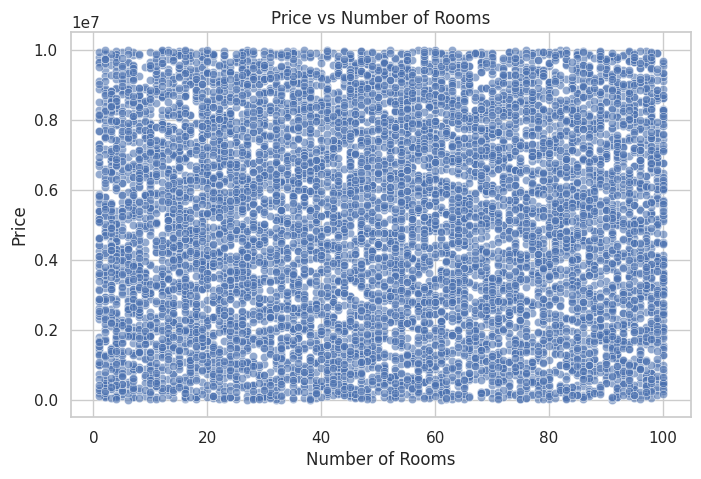

In [ ]:
# For better visual styles
sns.set(style="whitegrid")
# Scatter Plot: Price vs Number of Rooms
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='numberOfRooms', y='price', alpha=0.6)
plt.title('Price vs Number of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Price')
plt.show()


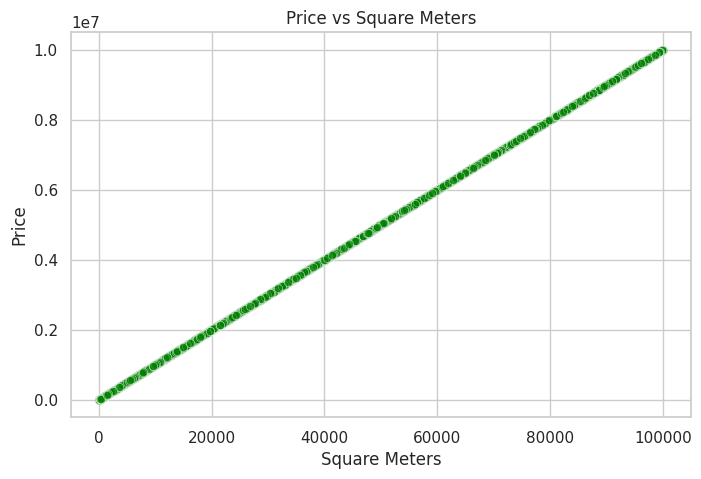

In [ ]:
# Scatter Plot: Price vs Square Meters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='squareMeters', y='price', alpha=0.6, color='green')
plt.title('Price vs Square Meters')
plt.xlabel('Square Meters')
plt.ylabel('Price')
plt.show()

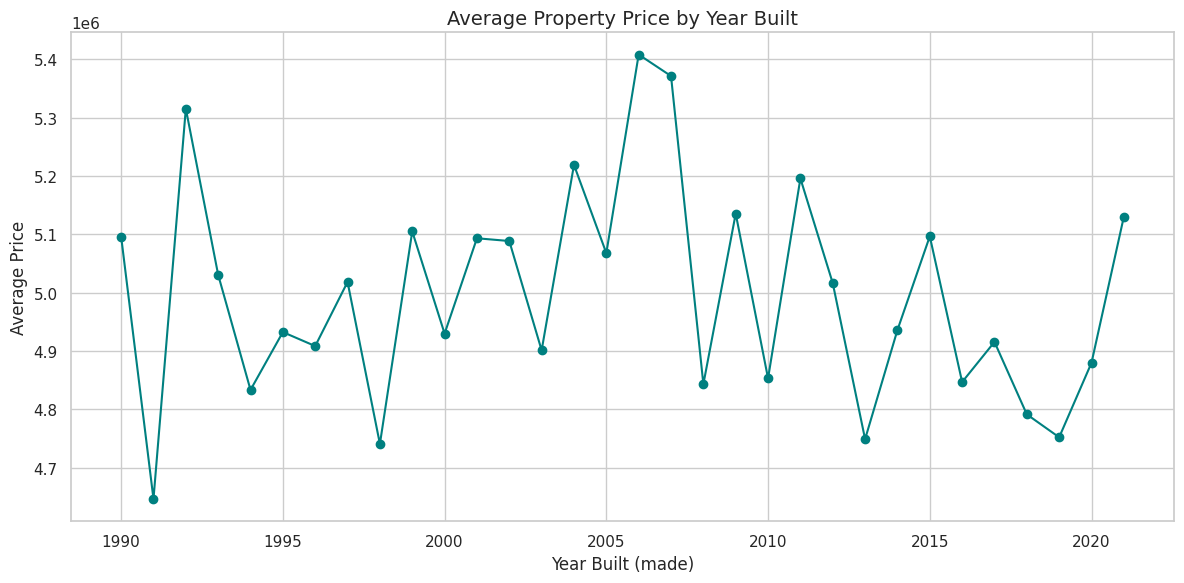

In [ ]:
# Group by 'made' year and calculate average price for each year
yearly_price_trend = data.groupby('made')['price'].mean().reset_index()

# Sort by year
yearly_price_trend = yearly_price_trend.sort_values(by='made')

# Plot
plt.figure(figsize=(12, 6))
plt.plot(yearly_price_trend['made'], yearly_price_trend['price'], marker='o', color='teal')
plt.title('Average Property Price by Year Built', fontsize=14)
plt.xlabel('Year Built (made)', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

**Feature Engineering**

A new feature was engineered to represent the number of properties constructed each year, specifically to support the temporal analysis and visualization of housing development trends over time

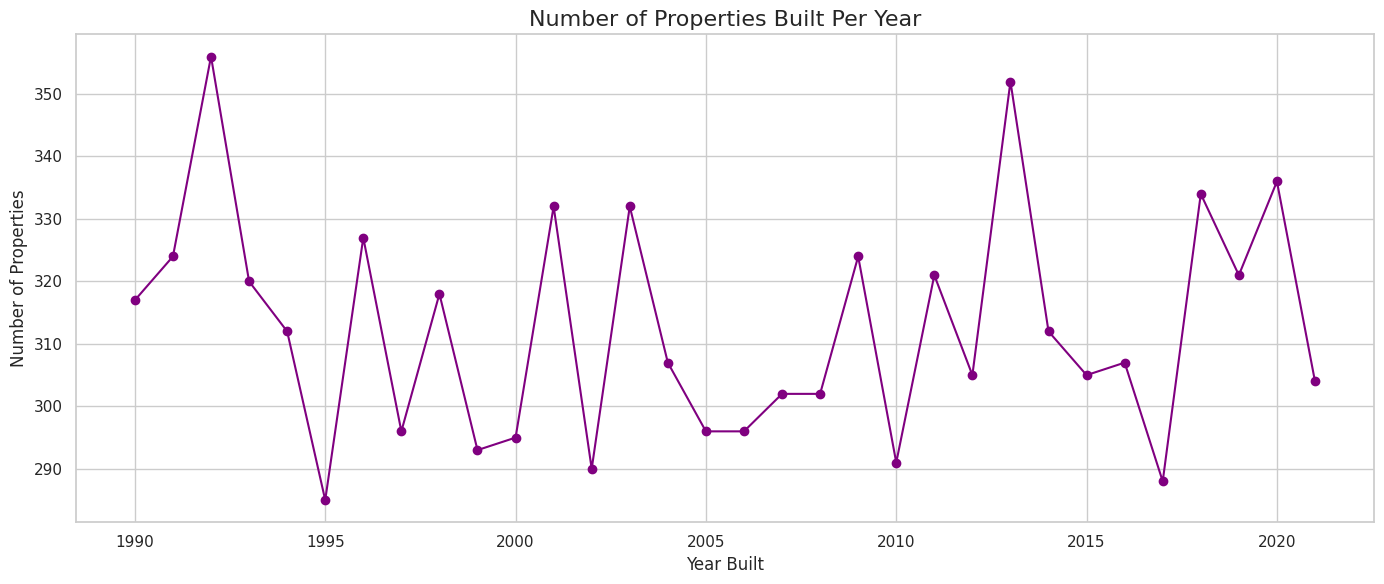

In [ ]:
# Create a new DataFrame with count of properties built each year
properties_per_year = data['made'].value_counts().sort_index()

# Convert to DataFrame
properties_per_year_df = properties_per_year.reset_index()
properties_per_year_df.columns = ['Year', 'Properties_Built']

# Plot the number of properties built each year
plt.figure(figsize=(14, 6))
plt.plot(properties_per_year_df['Year'], properties_per_year_df['Properties_Built'], marker='o', color='purple')
plt.title('Number of Properties Built Per Year', fontsize=16)
plt.xlabel('Year Built')
plt.ylabel('Number of Properties')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Create a dictionary of year -> count
yearly_counts_dict = properties_per_year.to_dict()

data_1 = data.copy()

# Map the counts back to the original dataset
data_1['properties_built_in_year'] = data_1['made'].map(yearly_counts_dict)
data_1.head()


,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,properties_built_in_year
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.500,296
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.500,305
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.100,304
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.200,305
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.000,317


In [ ]:
data_1.shape

(10000, 18)

# Data Preprocessing

Outlier Detection

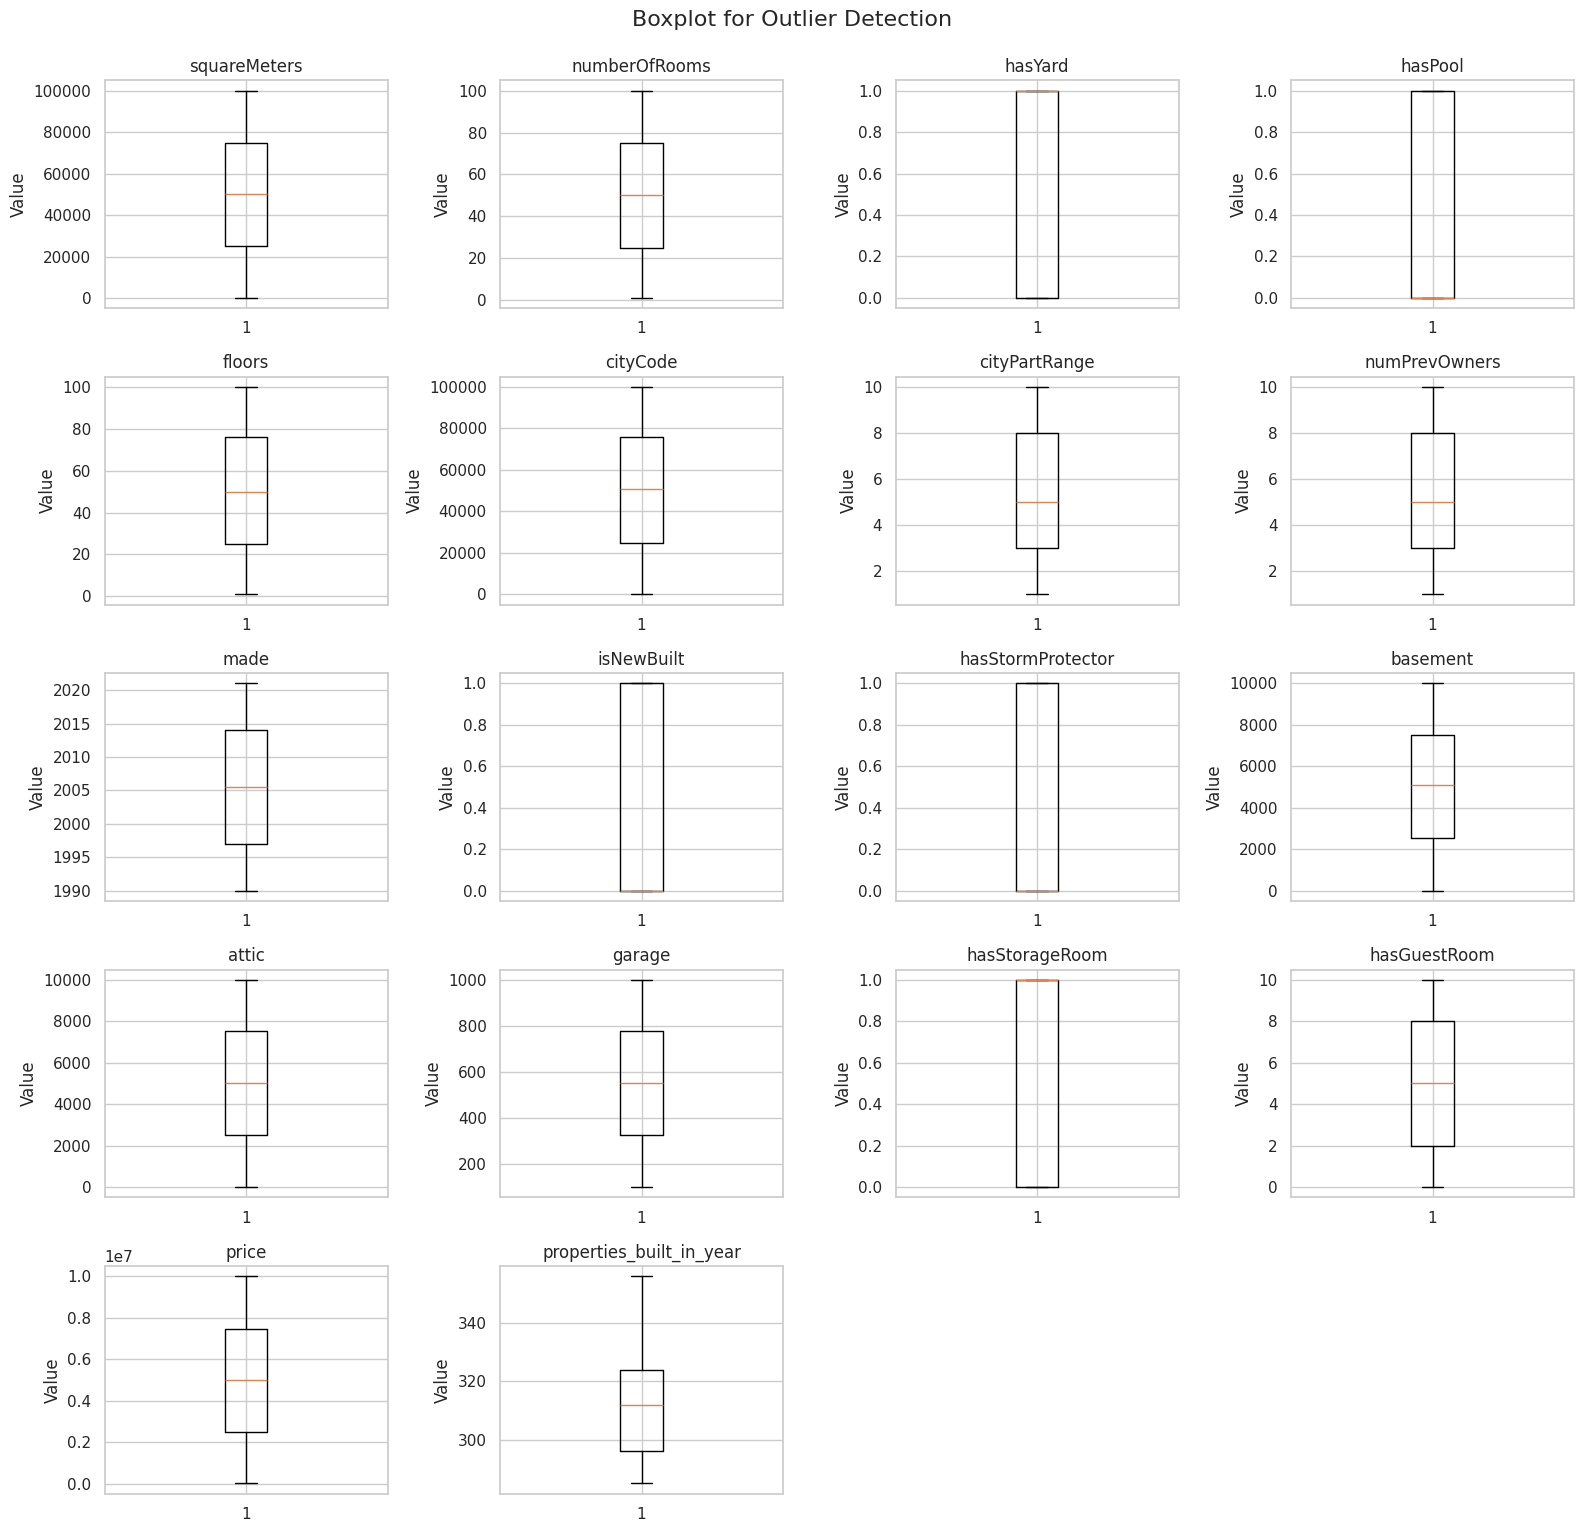

In [ ]:
# List of numeric columns
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
n_vars = len(numeric_columns)

# Calculate number of rows and columns dynamically
n_cols = 4
n_rows = int(np.ceil(n_vars / n_cols))

# Plot
plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, variable in enumerate(numeric_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.title(variable)
    plt.xlabel('')
    plt.ylabel('Value')

plt.tight_layout()
plt.suptitle("Boxplot for Outlier Detection", fontsize=16, y=1.02)
plt.show()


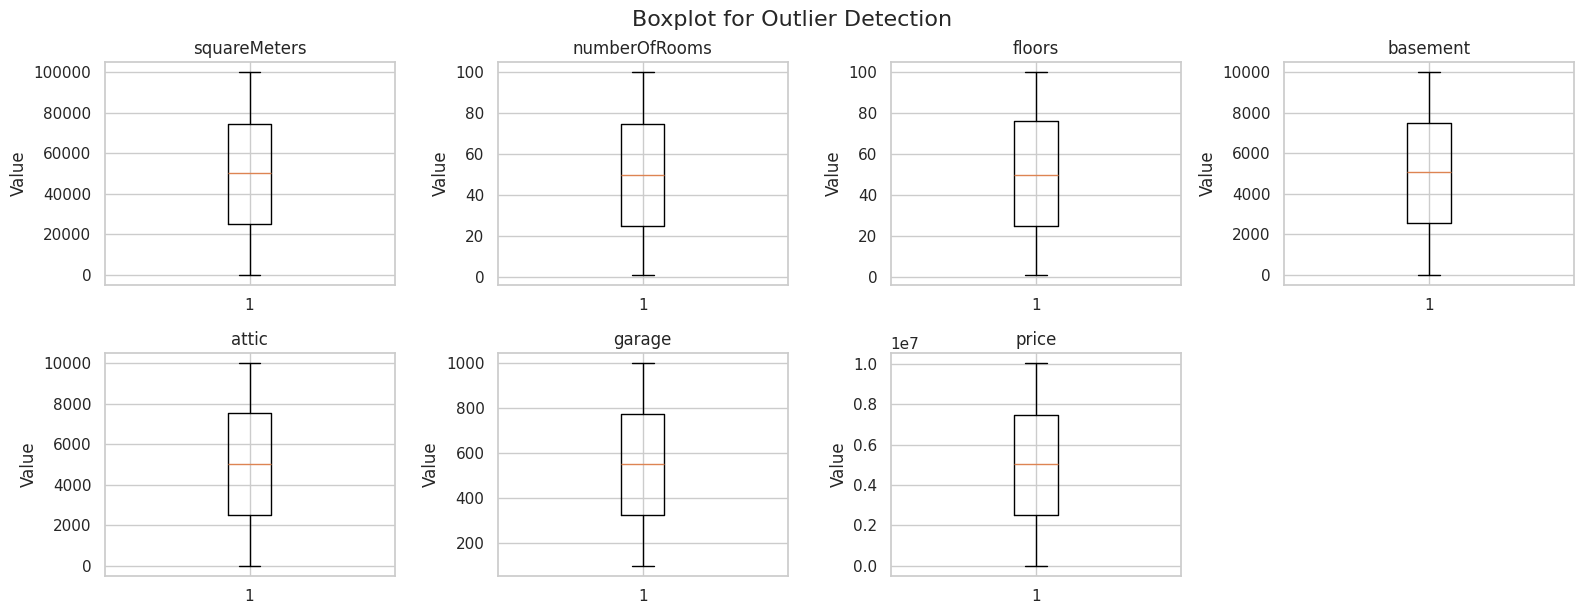

In [ ]:
# List of numeric columns
Outliers = ['squareMeters', 'numberOfRooms', 'floors', 'basement', 'attic', 'garage', 'price']
n_vars = len(Outliers)

# Calculate number of rows and columns dynamically
n_cols = 4
n_rows = int(np.ceil(n_vars / n_cols))

# Plot
plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, variable in enumerate(Outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.title(variable)
    plt.xlabel('')
    plt.ylabel('Value')

plt.tight_layout()
plt.suptitle("Boxplot for Outlier Detection", fontsize=16, y=1.02)
plt.show()


* Significant outliers are present in features like squareMeters, numberofRooms, floors, basement, attic, garage, and price indicating unusually large or high-value properties.

* The price variable shows a wide range with several extreme high values, which could impact model performance if not addressed.

* Mislead metrics like RMSE (which is sensitive to large errors).

In [ ]:
# Create a copy of the orginal data
df = data.copy()

In [ ]:
# Features and target Split
X = df.drop(columns=['price'])
y = df['price']

Scaling is not required for tree-based models (like Random Forest or XGBoost) since they split based on feature values, not distances or coefficients.

In [ ]:
# Normalize the features (Scaling for Linear Regression only)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Model Development

Linear Regression Serves as a strong baseline model when the relationship between features and target is assumed to be linear.

Random Forest Moderate to large datasets with non-linear patterns and potential outliers.

XGBoost complex datasets where fine-tuned predictive power is critical.

In [ ]:
# Define Metrics

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(rmse),
    'R2': make_scorer(r2_score)
}

# Initialize Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}


5-fold cross-validation was used to ensure reliable, unbiased model evaluation by testing each model across multiple data splits while maintaining a balance between accuracy and computation time.

In [ ]:
# Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for model_name, model in models.items():
    if model_name == 'Linear Regression':
        X_input = X_scaled
    else:
        X_input = X  # Tree models don't need scaling

    mae_scores = cross_val_score(model, X_input, y, cv=kf, scoring=scoring['MAE'])
    rmse_scores = cross_val_score(model, X_input, y, cv=kf, scoring=scoring['RMSE'])
    r2_scores = cross_val_score(model, X_input, y, cv=kf, scoring=scoring['R2'])

    results.append({
        'Model': model_name,
        'MAE': np.mean(mae_scores),
        'RMSE': np.mean(rmse_scores),
        'R²': np.mean(r2_scores)
    })


In [ ]:
# Final Performance Table
results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("Model Performance (5-Fold Cross Validation):\n")
print(results_df)


Model Performance (5-Fold Cross Validation):

               Model       MAE      RMSE    R²
0  Linear Regression  1481.150  1900.209 1.000
1      Random Forest  3094.420  3875.556 1.000
2            XGBoost 10608.379 12640.216 1.000


*INSIGHTS*

* **Linear Regression** performs the best among all models with the lowest MAE (1481.15) and RMSE (1900.21), and a perfect R² score (1.000). This suggests that the relationship between features and price is likely linear and well captured by a simple model.

* **Random Forest** also achieves a perfect R² score of 1.000, but with higher errors compared to Linear Regression (MAE: 3094.42, RMSE: 3875.56). It likely overfits slightly on synthetic data or does not generalize as well despite its complexity.

* **XGBoost Regressor** surprisingly performs worst among the three, with significantly higher error metrics (MAE: 10608.38, RMSE: 12640.22). Despite its R² score of 1.000, the higher errors suggest it might be overfitting or not well-tuned for this particular dataset.

* The **R² score of 1.000 across all model** strongly suggests the dataset is either synthetic or highly engineered (as your earlier EDA indicated), resulting in perfect predictability — this would rarely happen in real-world data.

# Feature importance:

**Feature Importance using Decision Tree Regressor**

A Decision Tree Regressor was used to identify the most influential features affecting house prices, with model-specific feature importance scores extracted and visualized.

In [ ]:
# Features and target
X_1 = data.drop('price', axis=1)
y_1 = data['price']

# If categorical variables exist, convert them using one-hot encoding
X_encoded = pd.get_dummies(X_1, drop_first=True)

# Train a Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_encoded, y)


DecisionTreeRegressor(random_state=42)

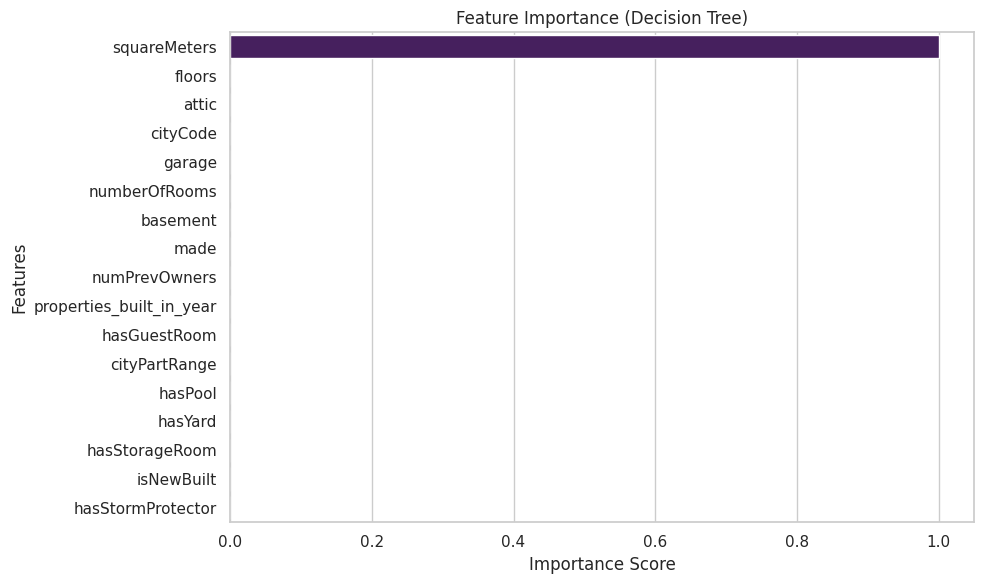

In [ ]:
# Extract feature importances
importances = pd.Series(dt_model.feature_importances_, index=X_encoded.columns)

# Sort by importance
importances_sorted = importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index, palette='viridis')
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


*OBSERVATIONS*

* **squareMeters** is overwhelmingly the most important feature influencing housing price. Its importance score is close to 1.0, which implies the model relies almost exclusively on this feature for making predictions.

All other features have negligible importance, indicating:

* Either their variation doesn’t contribute much to price prediction, or

* The information they provide is already captured or highly correlated with squareMeters.

# Model Deployment

* The trained machine learning model and StandardScaler were serialized using joblib to enable consistent predictions during deployment.



* An interactive web interface (app.py) was built using Streamlit, allowing users to input data, which is then preprocessed and passed to the model for prediction.



* A requirements.txt file was created to list all necessary Python packages, ensuring consistent environment setup during deployment.



* All project files—including the app script, model files, and dependencies—were pushed to a public GitHub repository for deployment.



* The GitHub repository was linked to Streamlit Cloud, where the app was deployed by specifying the branch and app.py file. Dependencies were automatically installed.



* The deployed app was tested for correctness. Any code changes were pushed to GitHub, triggering automatic redeployment on Streamlit Cloud.

In [ ]:
# Step 1: Install dependencies
# !pip install joblib

In [ ]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
import joblib

# Drop specified columns
data = data.drop(columns=['cityCode', 'numPrevOwners', 'made', 'hasGuestRoom'])

# Step 5: Feature-target split
X = data.drop('price', axis=1)
y = data['price']

# Step 6: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 7: Define metrics
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(rmse),
    'R2': make_scorer(r2_score)
}

# Step 8: Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

mae_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring=scoring['MAE'])
rmse_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring=scoring['RMSE'])
r2_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring=scoring['R2'])

# Step 9: Display performance
print("Linear Regression Performance (5-Fold CV):")
print(f"Mean MAE : {np.mean(mae_scores):.2f}")
print(f"Mean RMSE: {np.mean(rmse_scores):.2f}")
print(f"Mean R²  : {np.mean(r2_scores):.4f}")

# Step 10: Train final model on full data
model.fit(X_scaled, y)

Linear Regression Performance (5-Fold CV):
Mean MAE : 1480.20
Mean RMSE: 1899.73
Mean R²  : 1.0000


LinearRegression()

In [ ]:
# Step 11: Save model and scaler
joblib.dump(model, 'house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Model and Scaler saved as .pkl files")

✅ Model and Scaler saved as .pkl files


In [ ]:
# Step 12: Download the model files
from google.colab import files
files.download('house_price_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

In this project, a robust end-to-end house price prediction system was developed by applying systematic data preprocessing, exploratory analysis, and advanced regression modeling. Multiple regression models—including tree-based and linear approaches—were evaluated using cross-validation and performance metrics such as MAE, RMSE, and R², ensuring reliable selection of the best-performing model. Feature importance analysis highlighted that square footage, number of rooms, and location significantly influenced house prices.  

Finally, the trained model was successfully deployed through a user-friendly Streamlit web application, allowing real-time predictions based on user input. The project demonstrates the practical application of machine learning in real estate analytics and provides a scalable framework for future enhancements.